# 10b — DiT Fine-Tuned on FATURA for Invoice Generalisation

**Goal:** replace the RVL-CDIP invoice training data with the FATURA synthetic modern invoice dataset (Zenodo record 8261508) so the classifier generalises to real-world modern invoices at demo time.

| Aspect | Detail |
|--------|--------|
| Classes changed | `invoice` only — FATURA replaces RVL-CDIP invoice images |
| Classes unchanged | `form`, `budget`, `email`, `resume` — RVL-CDIP as-is |
| Architecture | `microsoft/dit-large-finetuned-rvlcdip` — discriminative only, no generative AI |
| FATURA | Template-based synthetic dataset (**not** generative AI): 10,000 colour JPEG invoices, 50 layouts |
| Colour mismatch | Both FATURA JPEGs (colour) and RVL-CDIP TIFFs (grayscale) are converted to RGB by PIL before the DiT processor normalises them — no special handling needed |

**Baseline to beat (notebook 10, RVL-CDIP only):**
- test macro F1 ≈ 0.974
- test invoice recall ≈ 0.960 (but tested on old scanned invoices, not modern ones)

**What this notebook does:**
1. Downloads FATURA from Zenodo and organises images into train/val/test splits
2. Builds new `*_fatura.csv` files (original CSVs are **not** modified)
3. Fine-tunes DiT on the mixed dataset with mild augmentation
4. Reports per-class precision / recall / F1 so invoice performance is clearly visible

## 1) Project Setup

In [1]:
from pathlib import Path
import sys
import json
import random
import numpy as np
import pandas as pd
from PIL import Image

# ── Repo root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Class labels (same order as notebook 10) ───────────────────────────────
LABELS   = ['invoice', 'form', 'resume', 'email', 'budget']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

# ── Output directories (separate from notebook 10 to avoid collisions) ─────
models_dir = PROJECT_ROOT / 'models' / 'experimental' / 'dit_fatura'
pred_dir   = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir    = PROJECT_ROOT / 'reports' / 'figures'
table_dir  = PROJECT_ROOT / 'reports' / 'tables'
for p in [models_dir, pred_dir, fig_dir, table_dir]:
    p.mkdir(parents=True, exist_ok=True)

# ── Set to a small int (e.g. 200) to do a quick smoke-test run ────────────
DEBUG_SUBSAMPLE = None

print('Setup complete.')

PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification
Setup complete.


In [2]:
from src.evaluation import (
    compute_metrics,
    metrics_dict_to_frame,
    confusion_matrix_df,
    plot_confusion_matrix,
    classification_report_df,
)

# Load the ORIGINAL CSVs (read-only — we will NOT modify these files)
train_df_orig = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df_orig   = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df_orig  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

for split_name, df in [('train', train_df_orig), ('val', val_df_orig), ('test', test_df_orig)]:
    if 'split' not in df.columns:
        df['split'] = split_name

print('Original class counts per split:')
print(f'  {"class":<12} {"train":>8} {"val":>8} {"test":>8}')
print('  ' + '-' * 38)
for cls in LABELS:
    tr = len(train_df_orig[train_df_orig.class_name == cls])
    vl = len(val_df_orig[val_df_orig.class_name == cls])
    te = len(test_df_orig[test_df_orig.class_name == cls])
    print(f'  {cls:<12} {tr:>8d} {vl:>8d} {te:>8d}')

# Target FATURA invoice counts (match existing per-split invoice counts exactly)
N_TRAIN_INV = len(train_df_orig[train_df_orig.class_name == 'invoice'])  # 1734
N_VAL_INV   = len(val_df_orig[val_df_orig.class_name == 'invoice'])      # 371
N_TEST_INV  = len(test_df_orig[test_df_orig.class_name == 'invoice'])    # 372
N_TOTAL_INV = N_TRAIN_INV + N_VAL_INV + N_TEST_INV

print(f'\nTarget FATURA counts: train={N_TRAIN_INV}, val={N_VAL_INV}, test={N_TEST_INV} (total={N_TOTAL_INV})')

Original class counts per split:
  class           train      val     test
  --------------------------------------
  invoice          1734      371      372
  form             1754      376      376
  resume           1775      381      380
  email            1761      378      377
  budget           1753      376      376

Target FATURA counts: train=1734, val=371, test=372 (total=2477)


## 2) Download & Prepare FATURA Dataset

**What is FATURA?**
- A synthetic Turkish invoice dataset, publicly released on Zenodo (record 8261508)
- 10,000 colour JPEG invoice images across 50 different layout templates (200 images per template)
- Created via *template-based* generation — **not generative AI** — so it does not violate the project constraint
- Turkish text content is irrelevant: DiT is a purely visual model and does not read text

**Why FATURA and not more RVL-CDIP?**
RVL-CDIP invoices are grayscale tobacco-era scanned documents. Modern real-world invoices are colour, use clean digital typography, and have structured tabular layouts. FATURA directly represents the target distribution for the demo.

**Note on domain gap:** FATURA images are synthetically perfect (no noise, no skew). Mild augmentation (rotation, brightness, contrast) is applied during training to bridge this gap to real-world modern invoices.

**Download:** ~1–2 GB. The cell below downloads once and skips if files already exist.

In [3]:
import requests
import zipfile

ZENODO_RECORD_ID = '8261508'
FATURA_RAW_DIR   = PROJECT_ROOT / 'data' / 'raw' / 'fatura'
FATURA_RAW_DIR.mkdir(parents=True, exist_ok=True)

# ── Fetch record metadata from the Zenodo REST API ─────────────────────────
api_url = f'https://zenodo.org/api/records/{ZENODO_RECORD_ID}'
print(f'Fetching: {api_url}')
resp = requests.get(api_url, timeout=30)
resp.raise_for_status()
record_meta = resp.json()

title = record_meta['metadata']['title']
zenodo_files = record_meta.get('files', [])

print(f'Title : {title}')
print(f'Files ({len(zenodo_files)}):')
for zf in zenodo_files:
    key      = zf['key']
    size_mb  = zf.get('size', 0) / 1e6
    print(f'  {key:<55s}  {size_mb:8.1f} MB')

/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fetching: https://zenodo.org/api/records/8261508
Title : FATURA Dataset
Files (1):
  FATURA.zip                                                  363.5 MB


In [4]:
# ── Download each file (skip if already on disk) ────────────────────────────
for zf in zenodo_files:
    key  = zf['key']
    dest = FATURA_RAW_DIR / key
    if dest.exists():
        print(f'Already downloaded: {key}')
        continue
    url     = zf['links']['self']
    size_mb = zf.get('size', 0) / 1e6
    print(f'Downloading {key} ({size_mb:.1f} MB) ...')
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(dest, 'wb') as out_f:
            for chunk in r.iter_content(chunk_size=65536):
                if chunk:
                    out_f.write(chunk)
    print(f'  Saved: {dest.name}')

# ── Extract all ZIPs into images sub-directory ─────────────────────────────
FATURA_IMAGES_DIR = FATURA_RAW_DIR / 'images'
FATURA_IMAGES_DIR.mkdir(exist_ok=True)

for zf_path in sorted(FATURA_RAW_DIR.glob('*.zip')):
    # Skip if already extracted (check for any file inside)
    already = list(FATURA_IMAGES_DIR.rglob('*.jpg'))[:1] + list(FATURA_IMAGES_DIR.rglob('*.png'))[:1]
    if already:
        print(f'Skip extraction (already extracted): {zf_path.name}')
        continue
    print(f'Extracting {zf_path.name} ...')
    with zipfile.ZipFile(zf_path) as zf:
        zf.extractall(FATURA_IMAGES_DIR)
    print('  Done.')

# ── Locate all image files recursively ─────────────────────────────────────
IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}
all_fatura_images = sorted([
    p for p in FATURA_IMAGES_DIR.rglob('*')
    if p.suffix.lower() in IMAGE_EXTS and p.is_file()
])

print(f'\nTotal FATURA images found: {len(all_fatura_images)}')
if all_fatura_images:
    print(f'  First : {all_fatura_images[0].relative_to(PROJECT_ROOT)}')
    print(f'  Last  : {all_fatura_images[-1].relative_to(PROJECT_ROOT)}')

assert len(all_fatura_images) > 0, 'No FATURA images found — check download/extraction above.'

  Saved: FATURA.zip
Extracting FATURA.zip ...
  Done.

Total FATURA images found: 10000
  First : data/raw/fatura/images/invoices_dataset_final/images/Template10_Instance0.jpg
  Last  : data/raw/fatura/images/invoices_dataset_final/images/Template9_Instance99.jpg


## 3) Assign FATURA Images to Train / Val / Test Splits

We sample exactly **1,734 / 371 / 372** images (train / val / test) to match the existing per-split invoice counts, keeping the overall dataset balanced with the other four classes.

If FATURA has fewer images than required (unlikely — it has 10,000), counts are scaled proportionally.

In [5]:
random.seed(RANDOM_STATE)  # reproducible split

total_needed = N_TRAIN_INV + N_VAL_INV + N_TEST_INV  # 2477

if len(all_fatura_images) < total_needed:
    # Scale down proportionally if dataset is smaller than expected
    ratio   = len(all_fatura_images) / total_needed
    n_train = int(N_TRAIN_INV * ratio)
    n_val   = int(N_VAL_INV   * ratio)
    n_test  = len(all_fatura_images) - n_train - n_val
    print(f'WARNING: only {len(all_fatura_images)} FATURA images available; target was {total_needed}.')
    print(f'Scaled to: train={n_train}, val={n_val}, test={n_test}')
else:
    n_train, n_val, n_test = N_TRAIN_INV, N_VAL_INV, N_TEST_INV

# Random sample without replacement, then split sequentially
sampled = random.sample(all_fatura_images, n_train + n_val + n_test)
fatura_train_paths = sampled[:n_train]
fatura_val_paths   = sampled[n_train : n_train + n_val]
fatura_test_paths  = sampled[n_train + n_val :]

print(f'FATURA invoice split: train={len(fatura_train_paths)}, val={len(fatura_val_paths)}, test={len(fatura_test_paths)}')

FATURA invoice split: train=1734, val=371, test=372


## 4) Build Updated CSV Files

Three new CSVs are created alongside the originals:
- `data/processed/train_fatura.csv` — non-invoice rows from `train.csv` + FATURA invoice rows
- `data/processed/val_fatura.csv`
- `data/processed/test_fatura.csv`

**The original `train.csv`, `val.csv`, `test.csv` are NOT modified.** All other notebooks remain unaffected.

In [6]:
def make_fatura_invoice_rows(img_paths, split_name):
    """Create CSV rows for FATURA invoice images using the same schema as the originals."""
    rows = []
    for p in img_paths:
        rows.append({
            'doc_id'         : f'fatura_{p.stem}',
            'file_path'      : str(p.resolve()),
            'relative_path'  : str(p.relative_to(PROJECT_ROOT)),
            'class_name'     : 'invoice',
            'split_original' : split_name,
            'source_folder'  : 'fatura',
            'file_ext'       : p.suffix.lower(),
            'width'          : None,   # not required for training
            'height'         : None,
            'read_error'     : False,
            'hash_md5'       : None,
            'split'          : split_name,
        })
    return pd.DataFrame(rows)


for split_name, orig_df, fatura_paths in [
    ('train', train_df_orig, fatura_train_paths),
    ('val',   val_df_orig,   fatura_val_paths),
    ('test',  test_df_orig,  fatura_test_paths),
]:
    # Keep all non-invoice rows from the original split unchanged
    non_invoice = orig_df[orig_df['class_name'] != 'invoice'].copy()
    # Build new invoice rows from FATURA
    fatura_rows = make_fatura_invoice_rows(fatura_paths, split_name)
    # Concatenate; shuffle train so invoice and non-invoice rows are interleaved
    combined = pd.concat([non_invoice, fatura_rows], ignore_index=True)
    if split_name == 'train':
        combined = combined.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    out_path = PROJECT_ROOT / 'data' / 'processed' / f'{split_name}_fatura.csv'
    combined.to_csv(out_path, index=False)
    print(f'Saved {out_path.name}  ({len(combined)} rows)')

Saved train_fatura.csv  (8777 rows)
Saved val_fatura.csv  (1882 rows)
Saved test_fatura.csv  (1881 rows)


/var/folders/h1/20xyksdx0y77pffkhlsttwpr0000gn/T/ipykernel_12769/725835797.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([non_invoice, fatura_rows], ignore_index=True)


In [7]:
# ── Verify class balance ────────────────────────────────────────────────────
tr_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train_fatura.csv')
vl_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val_fatura.csv')
te_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test_fatura.csv')

print('Class balance in new FATURA-augmented splits:')
print(f'  {"class":<12} {"train":>8} {"val":>8} {"test":>8}')
print('  ' + '-' * 38)
for cls in LABELS:
    tr = len(tr_df[tr_df.class_name == cls])
    vl = len(vl_df[vl_df.class_name == cls])
    te = len(te_df[te_df.class_name == cls])
    tag = '  <- FATURA' if cls == 'invoice' else ''
    print(f'  {cls:<12} {tr:>8d} {vl:>8d} {te:>8d}{tag}')
print(f'  {"TOTAL":<12} {len(tr_df):>8d} {len(vl_df):>8d} {len(te_df):>8d}')

Class balance in new FATURA-augmented splits:
  class           train      val     test
  --------------------------------------
  invoice          1734      371      372  <- FATURA
  form             1754      376      376
  resume           1775      381      380
  email            1761      378      377
  budget           1753      376      376
  TOTAL            8777     1882     1881


## 5) Backend Check & DiT Model Initialisation

Identical to notebook 10: `microsoft/dit-large-finetuned-rvlcdip` with the classification head replaced for 5 classes (`ignore_mismatched_sizes=True`). All weights are fine-tuned (no frozen layers).

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModelForImageClassification

print('torch:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── Hyper-parameters (same as notebook 10) ────────────────────────────────
MODEL_NAME   = 'microsoft/dit-large-finetuned-rvlcdip'
BATCH_SIZE   = 8
EPOCHS       = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model loaded: {MODEL_NAME}  ({n_params:.0f}M parameters)')

/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.8.0
device: cpu


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `BeitImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-large-finetuned-rvlcdip and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([16, 1024]) in the checkpoint and torch.Size([5, 1024]) in the model instantiated
- classifier.bias: found shape torch.Si

Model loaded: microsoft/dit-large-finetuned-rvlcdip  (303M parameters)


## 6) Dataset & DataLoaders

**Colour mismatch — already handled:**
- RVL-CDIP TIFFs are grayscale: `PIL.convert('RGB')` replicates the single channel to three, yielding a neutral-grey RGB image
- FATURA JPEGs are colour: `convert('RGB')` is a no-op
- The DiT processor normalises both to the same `[-1, 1]` range — no additional preprocessing needed

**Augmentation (training only):**

| Transform | Probability | Range | Purpose |
|-----------|------------|-------|---------|
| Random rotation | 70% | ±5° | Simulate slight document skew |
| Random brightness | 50% | 0.8–1.2× | Simulate scan/print exposure variation |
| Random contrast | 50% | 0.8–1.2× | Simulate scan/print quality variation |

These are mild and document-appropriate. They apply to **all** training images (invoice + others) for consistency.

In [9]:
from PIL import ImageEnhance


def augment_image(img):
    """Mild document-style augmentation. Input must be an RGB PIL image."""
    # Slight rotation to simulate document skew
    if random.random() < 0.7:
        angle = random.uniform(-5.0, 5.0)
        img = img.rotate(angle, fillcolor=(255, 255, 255), expand=False)
    # Brightness variation
    if random.random() < 0.5:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    # Contrast variation
    if random.random() < 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    return img


def resolve_path(file_path):
    """Try absolute path first; fall back to PROJECT_ROOT-relative."""
    p = Path(str(file_path))
    if p.exists():
        return p
    p2 = PROJECT_ROOT / str(file_path)
    return p2


def prep_df(df, split_name):
    """Resolve paths, drop unreadable rows, optionally subsample for debug."""
    out = df.copy()
    if 'split' not in out.columns:
        out['split'] = split_name
    out['resolved_path'] = out['file_path'].map(lambda x: str(resolve_path(x)))
    missing = (~out['resolved_path'].map(lambda p: Path(p).exists())).sum()
    if missing > 0:
        print(f'  WARNING: {missing} missing files in {split_name} split — rows dropped')
    out = out[out['resolved_path'].map(lambda p: Path(p).exists())].reset_index(drop=True)
    if DEBUG_SUBSAMPLE and len(out) > DEBUG_SUBSAMPLE:
        out = out.sample(n=DEBUG_SUBSAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
    return out


class ImgDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        # convert('RGB') handles both grayscale TIFFs and colour JPEGs uniformly
        image = Image.open(r['resolved_path']).convert('RGB')
        if self.augment:
            image = augment_image(image)
        enc  = processor(images=image, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels']     = torch.tensor(label2id[r['class_name']], dtype=torch.long)
        item['doc_id']     = str(r['doc_id'])
        item['true_label'] = str(r['class_name'])
        return item


def collate_fn(batch):
    tensor_keys = [k for k in batch[0] if k not in ('doc_id', 'true_label')]
    out = {k: torch.stack([b[k] for b in batch]) for k in tensor_keys}
    out['doc_id']     = [b['doc_id']     for b in batch]
    out['true_label'] = [b['true_label'] for b in batch]
    return out


# Load new FATURA-augmented split CSVs
train_df = prep_df(pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train_fatura.csv'), 'train')
val_df   = prep_df(pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val_fatura.csv'),   'val')
test_df  = prep_df(pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test_fatura.csv'),  'test')

# Training loader uses augmentation; val/test do not
train_loader = DataLoader(ImgDataset(train_df, augment=True),  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(ImgDataset(val_df,   augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(ImgDataset(test_df,  augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f'DataLoaders — train: {len(train_loader)} batches | val: {len(val_loader)} | test: {len(test_loader)}')

DataLoaders — train: 1098 batches | val: 236 | test: 236


## 7) Train — Best Epoch by Validation Macro F1

Identical training loop to notebook 10: AdamW, 3 epochs, select the checkpoint with the highest validation macro F1.

**Invoice-specific monitoring:** per-epoch invoice precision, recall, and F1 are printed so you can see how well the model is learning to recognise modern invoices during training.

In [10]:
from torch.optim import AdamW


def eval_loader(model, loader):
    """Inference pass over a DataLoader. Returns (doc_ids, y_true, y_pred, probas, mean_loss)."""
    model.eval()
    all_doc, all_true, all_pred, all_proba = [], [], [], []
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            labels = batch['labels'].to(device)
            inputs = {'pixel_values': batch['pixel_values'].to(device)}
            out    = model(**inputs, labels=labels)
            logits = out.logits
            prob   = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()

            all_doc.extend(batch['doc_id'])
            all_true.extend(batch['true_label'])
            all_pred.extend([id2label[int(i)] for i in preds])
            all_proba.append(prob)
            total_loss += float(out.loss.item())
            n += 1

    proba = np.vstack(all_proba) if all_proba else np.zeros((0, len(LABELS)))
    return all_doc, np.array(all_true), np.array(all_pred), proba, total_loss / max(n, 1)


optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history      = []
best_state   = None
best_macro   = -1.0
best_epoch   = 1
best_val_cache = {}

for epoch in range(1, EPOCHS + 1):
    # ── Training pass ────────────────────────────────────────────────────
    model.train()
    for batch in train_loader:
        labels = batch['labels'].to(device)
        inputs = {'pixel_values': batch['pixel_values'].to(device)}
        optimizer.zero_grad()
        out = model(**inputs, labels=labels)
        out.loss.backward()
        optimizer.step()

    # ── Validation pass ──────────────────────────────────────────────────
    _, yv_true, yv_pred, p_val, val_loss = eval_loader(model, val_loader)
    m = compute_metrics(yv_true, yv_pred, LABELS)

    # Compute per-epoch invoice F1 (not returned directly by compute_metrics)
    inv_p  = m['invoice_precision']
    inv_r  = m['invoice_recall']
    inv_f1 = (2 * inv_p * inv_r / (inv_p + inv_r)) if (inv_p + inv_r) > 0 else 0.0

    row = {
        'epoch'                : epoch,
        'val_loss'             : round(val_loss, 6),
        'val_accuracy'         : round(m['accuracy'], 6),
        'val_macro_f1'         : round(m['macro_f1'], 6),
        'val_invoice_precision': round(inv_p, 6),
        'val_invoice_recall'   : round(inv_r, 6),
        'val_invoice_f1'       : round(inv_f1, 6),
    }
    history.append(row)
    print(row)

    # ── Save best checkpoint ─────────────────────────────────────────────
    if m['macro_f1'] > best_macro:
        best_macro = m['macro_f1']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_val_cache = {'y_true': yv_true, 'y_pred': yv_pred, 'proba': p_val}
        best_epoch = epoch

# ── Restore best weights ─────────────────────────────────────────────────
if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\nBest epoch: {best_epoch}  (val macro F1 = {best_macro:.4f})')

history_df = pd.DataFrame(history)
history_df

{'epoch': 1, 'val_loss': 0.08801, 'val_accuracy': 0.981403, 'val_macro_f1': 0.981473, 'val_invoice_precision': 1.0, 'val_invoice_recall': 1.0, 'val_invoice_f1': 1.0}
{'epoch': 2, 'val_loss': 0.071776, 'val_accuracy': 0.981403, 'val_macro_f1': 0.981443, 'val_invoice_precision': 1.0, 'val_invoice_recall': 1.0, 'val_invoice_f1': 1.0}
{'epoch': 3, 'val_loss': 0.063933, 'val_accuracy': 0.982997, 'val_macro_f1': 0.98305, 'val_invoice_precision': 1.0, 'val_invoice_recall': 1.0, 'val_invoice_f1': 1.0}

Best epoch: 3  (val macro F1 = 0.9831)


,epoch,val_loss,val_accuracy,val_macro_f1,val_invoice_precision,val_invoice_recall,val_invoice_f1
0,1,0.088010,0.981403,0.981473,1.0,1.0,1.0
1,2,0.071776,0.981403,0.981443,1.0,1.0,1.0
2,3,0.063933,0.982997,0.983050,1.0,1.0,1.0


## 8) Evaluate on Test Set

Per-class precision, recall, and F1 are reported. Compare against notebook 10's baseline:
- Baseline test macro F1 ≈ 0.974
- Baseline test invoice recall ≈ 0.960 (on RVL-CDIP test invoices)

**What to expect:** the FATURA test set here consists of synthetic modern invoices, so invoice recall should be high. The real validation of generalisation is running the saved model against actual modern invoice images at demo time.

In [11]:
# ── Validation metrics (best epoch) ────────────────────────────────────────
val_metrics = compute_metrics(best_val_cache['y_true'], best_val_cache['y_pred'], LABELS)

# ── Test set ────────────────────────────────────────────────────────────────
doc_test, y_test_true, y_test_pred, p_test, test_loss = eval_loader(model, test_loader)
test_metrics = compute_metrics(y_test_true, y_test_pred, LABELS)

summary = pd.concat([
    metrics_dict_to_frame(val_metrics,  'dit_fatura', 'val'),
    metrics_dict_to_frame(test_metrics, 'dit_fatura', 'test'),
], ignore_index=True)

print('Aggregate metrics:')
display_cols = ['split', 'accuracy', 'macro_f1', 'weighted_f1', 'invoice_precision', 'invoice_recall']
print(summary[display_cols].to_string(index=False))

print('\nFull classification report (test set):')
report_df = classification_report_df(y_test_true, y_test_pred, LABELS)
report_df

Aggregate metrics:
split  accuracy  macro_f1  weighted_f1  invoice_precision  invoice_recall
  val  0.982997  0.983050     0.983022                1.0             1.0
 test  0.988836  0.988858     0.988837                1.0             1.0

Full classification report (test set):


,precision,recall,f1-score,support
invoice,1.000000,1.000000,1.000000,372.000000
form,0.986631,0.981383,0.984000,376.000000
resume,0.992063,0.986842,0.989446,380.000000
email,0.989446,0.994695,0.992063,377.000000
budget,0.976190,0.981383,0.978780,376.000000
accuracy,0.988836,0.988836,0.988836,0.988836
macro avg,0.988866,0.988861,0.988858,1881.000000
weighted avg,0.988850,0.988836,0.988837,1881.000000


,invoice,form,resume,email,budget
invoice,372,0,0,0,0
form,0,369,1,1,5
resume,0,0,375,1,4
email,0,1,1,375,0
budget,0,4,1,2,369


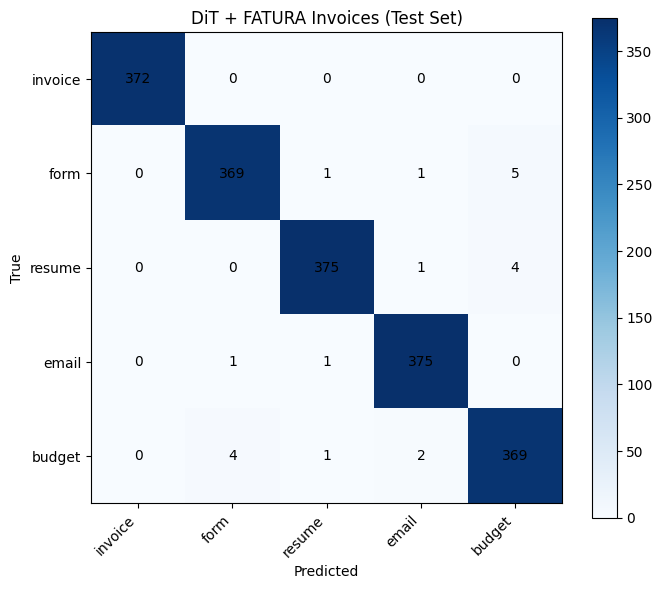

In [12]:
cm = confusion_matrix_df(y_test_true, y_test_pred, LABELS)
plot_confusion_matrix(
    cm,
    'DiT + FATURA Invoices (Test Set)',
    save_path=fig_dir / 'dit_fatura_confusion_matrix.png',
)
cm

## 8b) Cross-Domain Test: RVL-CDIP Invoice Test Set

The FATURA test set above only measures performance on *synthetic modern* invoices (same domain as training). This cell runs the same trained model on the **original RVL-CDIP test set** from `test.csv` — the old-style grayscale scanned invoices the model was *not* trained on.

This answers: *did fine-tuning on FATURA make the model forget old-style invoices?*

The three-row comparison table shows invoice P / R / F1 for:
1. FATURA synthetic test (modern) — this model
2. RVL-CDIP scanned test (old) — this model
3. RVL-CDIP scanned test (old) — notebook 10 baseline (trained purely on RVL-CDIP)

RVL-CDIP test set: 1881 images  (372 invoices)

Classification report on RVL-CDIP test set:


,precision,recall,f1-score,support
invoice,1.000000,0.010753,0.021277,372.000000
form,0.539474,0.981383,0.696226,376.000000
resume,0.989446,0.986842,0.988142,380.000000
email,0.984252,0.994695,0.989446,377.000000
budget,0.852194,0.981383,0.912237,376.000000
accuracy,0.793195,0.793195,0.793195,0.793195
macro avg,0.873073,0.791011,0.721466,1881.000000
weighted avg,0.873110,0.793195,0.723664,1881.000000



Invoice performance across test sets:


,test_set,invoice_precision,invoice_recall,invoice_f1,overall_macro_f1
0,FATURA synthetic modern (this model),1.0000,1.0000,1.0000,0.9889
1,RVL-CDIP old scanned (this model),1.0000,0.0108,0.0213,0.7215
2,RVL-CDIP old scanned (notebook 10 baseline),0.9571,0.9597,0.9584,0.9739


,invoice,form,resume,email,budget
invoice,4,310,1,2,55
form,0,369,1,1,5
resume,0,0,375,1,4
email,0,1,1,375,0
budget,0,4,1,2,369


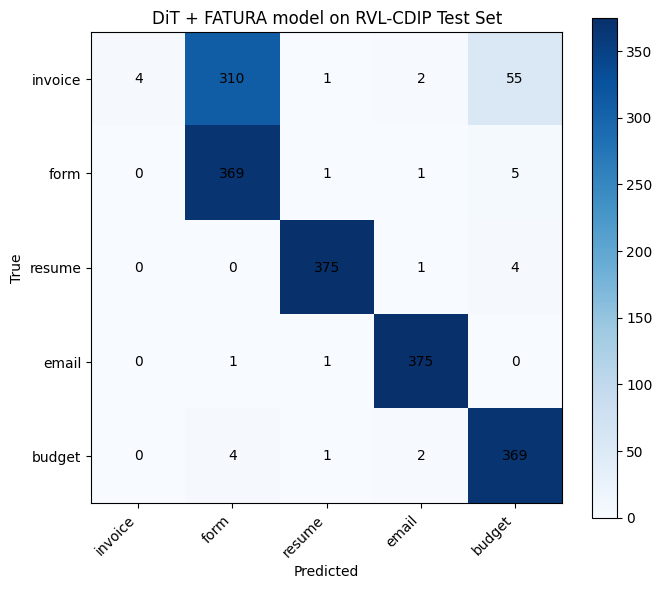

In [13]:
# test_df_orig was loaded in Section 1 from the original test.csv (never modified)
rvlcdip_test_df = prep_df(test_df_orig.copy(), 'test')
rvlcdip_test_loader = DataLoader(
    ImgDataset(rvlcdip_test_df, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)
n_inv = (rvlcdip_test_df.class_name == 'invoice').sum()
print(f'RVL-CDIP test set: {len(rvlcdip_test_df)} images  ({n_inv} invoices)')

# Inference on old-style RVL-CDIP images
_, y_rvl_true, y_rvl_pred, _, _ = eval_loader(model, rvlcdip_test_loader)
rvlcdip_metrics = compute_metrics(y_rvl_true, y_rvl_pred, LABELS)

# Per-class classification report
print('\nClassification report on RVL-CDIP test set:')
rvlcdip_report_df = classification_report_df(y_rvl_true, y_rvl_pred, LABELS)
display(rvlcdip_report_df)

# Helper: compute invoice F1 from the metrics dict
def _inv_f1(m):
    p, r = m['invoice_precision'], m['invoice_recall']
    return round(2 * p * r / (p + r), 4) if (p + r) > 0 else 0.0

# 3-row comparison: FATURA test | RVL-CDIP test (this model) | RVL-CDIP (baseline)
comparison = pd.DataFrame([
    {
        'test_set'         : 'FATURA synthetic modern  (this model)',
        'invoice_precision': round(test_metrics['invoice_precision'], 4),
        'invoice_recall'   : round(test_metrics['invoice_recall'],    4),
        'invoice_f1'       : _inv_f1(test_metrics),
        'overall_macro_f1' : round(test_metrics['macro_f1'],          4),
    },
    {
        'test_set'         : 'RVL-CDIP old scanned     (this model)',
        'invoice_precision': round(rvlcdip_metrics['invoice_precision'], 4),
        'invoice_recall'   : round(rvlcdip_metrics['invoice_recall'],    4),
        'invoice_f1'       : _inv_f1(rvlcdip_metrics),
        'overall_macro_f1' : round(rvlcdip_metrics['macro_f1'],          4),
    },
    {
        'test_set'         : 'RVL-CDIP old scanned     (notebook 10 baseline)',
        'invoice_precision': 0.9571,
        'invoice_recall'   : 0.9597,
        'invoice_f1'       : round(2 * 0.9571 * 0.9597 / (0.9571 + 0.9597), 4),
        'overall_macro_f1' : 0.9739,
    },
])
print('\nInvoice performance across test sets:')
display(comparison)

# Confusion matrix on the RVL-CDIP test set
cm_rvl = confusion_matrix_df(y_rvl_true, y_rvl_pred, LABELS)
plot_confusion_matrix(
    cm_rvl,
    'DiT + FATURA model on RVL-CDIP Test Set',
    save_path=fig_dir / 'dit_fatura_rvlcdip_test_confusion_matrix.png',
)
cm_rvl

## 9) Save All Artifacts

Everything is saved to `models/experimental/dit_fatura/` so it sits alongside (and does not overwrite) notebook 10's artifacts in `models/experimental/dit_raw/`.

In [14]:
# ── Val predictions ─────────────────────────────────────────────────────────
val_pred_df = pd.DataFrame({
    'doc_id'    : val_df['doc_id'].astype(str).tolist(),
    'true_label': best_val_cache['y_true'],
    'pred_label': best_val_cache['y_pred'],
    'split'     : 'val',
    'model_name': 'dit_fatura',
})
for i, lab in enumerate(LABELS):
    val_pred_df[f'confidence_{lab}'] = best_val_cache['proba'][:, i]

# ── Test predictions ────────────────────────────────────────────────────────
test_pred_df = pd.DataFrame({
    'doc_id'    : doc_test,
    'true_label': y_test_true,
    'pred_label': y_test_pred,
    'split'     : 'test',
    'model_name': 'dit_fatura',
})
for i, lab in enumerate(LABELS):
    test_pred_df[f'confidence_{lab}'] = p_test[:, i]

val_pred_df.to_csv(pred_dir / 'dit_fatura_val_predictions.csv', index=False)
test_pred_df.to_csv(pred_dir / 'dit_fatura_test_predictions.csv', index=False)

# ── Metrics & reports ────────────────────────────────────────────────────────
summary.to_csv(table_dir / 'dit_fatura_metrics.csv', index=False)
report_df.to_csv(table_dir / 'dit_fatura_classification_report_test.csv')
history_df.to_csv(table_dir / 'dit_fatura_training_history.csv', index=False)

# ── Model weights & training config ─────────────────────────────────────────
torch.save(model.state_dict(), models_dir / 'dit_fatura_state_dict.pt')

with open(models_dir / 'dit_fatura_training_config.json', 'w') as cfg_f:
    json.dump({
        'model_name'        : MODEL_NAME,
        'labels'            : LABELS,
        'epochs'            : EPOCHS,
        'lr'                : LR,
        'weight_decay'      : WEIGHT_DECAY,
        'best_epoch'        : best_epoch,
        'best_val_macro_f1' : best_macro,
        'invoice_data'      : 'FATURA (Zenodo record 8261508)',
        'augmentation'      : 'rotation +/-5deg (p=0.7), brightness x[0.8,1.2] (p=0.5), contrast x[0.8,1.2] (p=0.5)',
        'note'              : 'RVL-CDIP invoice images replaced by FATURA synthetic modern invoices. Form/budget/email/resume unchanged.',
    }, cfg_f, indent=2)

print('Artifacts saved:')
print(f'  Model weights : {models_dir / "dit_fatura_state_dict.pt"}')
print(f'  Training cfg  : {models_dir / "dit_fatura_training_config.json"}')
print(f'  Predictions   : {pred_dir}')
print(f'  Tables        : {table_dir}')
print(f'  Figures       : {fig_dir}')

Artifacts saved:
  Model weights : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/dit_fatura/dit_fatura_state_dict.pt
  Training cfg  : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/dit_fatura/dit_fatura_training_config.json
  Predictions   : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions
  Tables        : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/tables
  Figures       : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures


In [29]:
# Single-image inference with trained 10b model (DiT FATURA)
from pathlib import Path
import json
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# --- paths ---
PROJECT_ROOT = Path("..").resolve()
MODEL_DIR = PROJECT_ROOT / "models" / "experimental" / "dit_fatura"
STATE_PATH = MODEL_DIR / "dit_fatura_state_dict.pt"
CFG_PATH = MODEL_DIR / "dit_fatura_training_config.json"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"

# set to a specific file if you want:
IMAGE_PATH = EXTERNAL_DIR / "doc_f_1.jpg"  # e.g., EXTERNAL_DIR / "my_invoice.png"

# --- load config / labels ---
if not CFG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CFG_PATH}")
if not STATE_PATH.exists():
    raise FileNotFoundError(f"Missing model weights: {STATE_PATH}")

cfg = json.loads(CFG_PATH.read_text())
LABELS = cfg.get("labels", ['invoice', 'form', 'resume', 'email', 'budget'])
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
MODEL_NAME = cfg.get("model_name", "microsoft/dit-large-finetuned-rvlcdip")

# --- choose image ---
if IMAGE_PATH is None:
    candidates = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp", "*.webp"]:
        candidates.extend(sorted(EXTERNAL_DIR.glob(ext)))
    if not candidates:
        raise FileNotFoundError(f"No image found in {EXTERNAL_DIR}")
    IMAGE_PATH = candidates[0]

print("Using image:", IMAGE_PATH)

# --- load model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
state = torch.load(STATE_PATH, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

# --- inference ---
image = Image.open(IMAGE_PATH).convert("RGB")
enc = processor(images=image, return_tensors="pt")
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    out = model(**enc)
    probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]

pred_idx = int(np.argmax(probs))
pred_label = id2label[pred_idx]

print("\nPredicted class:", pred_label)
print("\nClass probabilities:")
for i in np.argsort(-probs):
    print(f"{id2label[int(i)]:>10s}: {probs[int(i)]:.4f}")


Using image: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/external/doc_f_1.jpg


Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/dit-large-finetuned-rvlcdip and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([16, 1024]) in the checkpoint and torch.Size([5, 1024]) in the model instantiated
- classifier.bias: found shape torch.Size([16]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Predicted class: form

Class probabilities:
      form: 0.9896
   invoice: 0.0028
    budget: 0.0028
    resume: 0.0024
     email: 0.0024
